In [1]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, TensorDataset

# Load dataset
df = pd.read_csv('../IMDB Dataset.csv')

# Cleaning function
def clean_review(text):
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['cleaned_review'] = df['review'].apply(clean_review)

# Labels
y = df['sentiment'].map({'negative': 0, 'positive': 1}).values

In [2]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 20000   # vocabulary size
max_len = 200       # max review length

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(df['cleaned_review'])
sequences = tokenizer.texts_to_sequences(df['cleaned_review'])
X = pad_sequences(sequences, maxlen=max_len)

# Train/val/test split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# Convert to tensors
X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1,1)
X_val_tensor = torch.LongTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val).reshape(-1,1)
X_test_tensor = torch.LongTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1,1)

# Data loaders
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=64)

In [3]:
import gensim.downloader as api
import numpy as np

# Load pretrained Word2Vec (GoogleNews, 300d)
word2vec = api.load("word2vec-google-news-300")  # ~1.6GB

embedding_dim = 300
vocab_size = max_words

# Create embedding matrix
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    if word in word2vec:
        embedding_matrix[i] = word2vec[word]
    else:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))  # OOV words

In [ ]:
import torch.nn as nn

import torch.nn as nn

class GRUModel(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim=128):
        super(GRUModel, self).__init__()
        
        num_embeddings, embedding_dim = embedding_matrix.shape
        
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix),
            freeze=False
        )
        
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.gru(x)
        
        x = hidden[-1]
        x = self.dropout(x)
        x = self.fc(x)
        
        return self.sigmoid(x)

hidden_dim = 128
model = GRUModel(embedding_matrix)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

GRUModel(
  (embedding): Embedding(20000, 300)
  (gru): GRU(300, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [ ]:
num_epochs = 10  # start with 10, could increase later if needed
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        pred = (outputs >= 0.5).float()
        train_total += batch_y.size(0)
        train_correct += (pred == batch_y).sum().item()
        
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            pred = (outputs >= 0.5).float()
            val_total += batch_y.size(0)
            val_correct += (pred == batch_y).sum().item()
            
    train_losses.append(train_loss/len(train_loader))
    val_losses.append(val_loss/len(val_loader))
    train_accuracies.append(100*train_correct/train_total)
    val_accuracies.append(100*val_correct/val_total)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Acc: {train_accuracies[-1]:.2f}% | Val Acc: {val_accuracies[-1]:.2f}%")

Epoch 1/10 | Train Acc: 79.04% | Val Acc: 87.05%
Epoch 2/10 | Train Acc: 92.00% | Val Acc: 89.14%
Epoch 3/10 | Train Acc: 96.13% | Val Acc: 90.02%
Epoch 4/10 | Train Acc: 98.07% | Val Acc: 89.26%
Epoch 5/10 | Train Acc: 99.22% | Val Acc: 89.10%
Epoch 6/10 | Train Acc: 99.61% | Val Acc: 88.55%
Epoch 7/10 | Train Acc: 99.60% | Val Acc: 87.74%
Epoch 8/10 | Train Acc: 99.73% | Val Acc: 88.05%
Epoch 9/10 | Train Acc: 99.60% | Val Acc: 87.67%
Epoch 10/10 | Train Acc: 99.84% | Val Acc: 88.08%


In [6]:
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_predictions = (test_outputs >= 0.5).float()
    test_accuracy = (test_predictions == y_test_tensor).float().mean()
    print(f"Test Accuracy: {test_accuracy:.2%}")
    y_true, y_pred = y_test_tensor.numpy(), test_predictions.numpy()

Test Accuracy: 88.34%


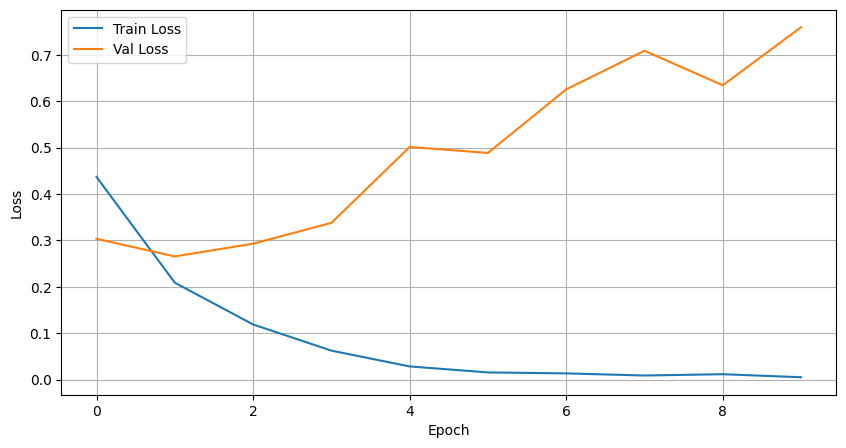

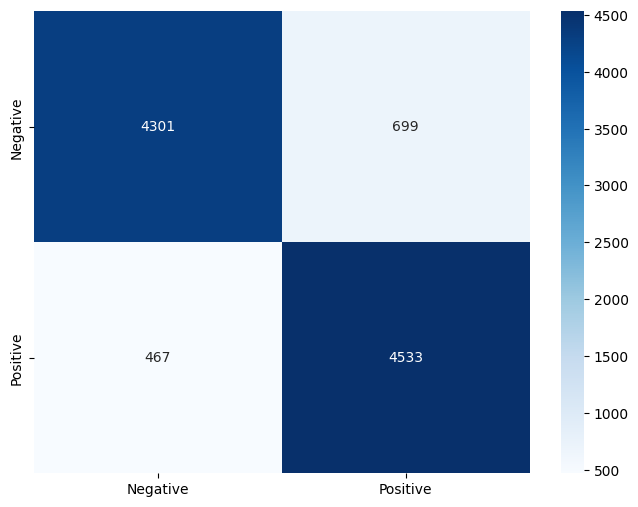

 Results discussion saved to ../results/gru_word2vec/results_discussion.txt

 ALL DONE! GRU saved correctly!


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

os.makedirs('../model', exist_ok=True)
os.makedirs('../results/gru_word2vec', exist_ok=True)

torch.save(model.state_dict(), '../model/gru_word2vec.pth')

# Loss curves
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('../results/gru_word2vec/loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'])
plt.savefig('../results/gru_word2vec/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Metrics
with open('../results/gru_word2vec/metrics.txt','w') as f:
    f.write("GRU Model - Evaluation Metrics\n\n")
    f.write(f"Test Accuracy: {test_accuracy:.2%}\n\n")
    f.write(classification_report(y_true, y_pred))

# results discussion
with open('../results/gru_word2vec/results_discussion.txt', 'w') as f:
    f.write("="*50 + "\n")
    f.write("GRU - RESULTS DISCUSSION\n")
    f.write("="*50 + "\n\n")
    
    f.write(f"Model Performance:\n")
    f.write(f"- Test Accuracy: {test_accuracy:.2%}\n")
    f.write(f"- Training Accuracy (final): {train_accuracies[-1]:.2f}%\n")
    f.write(f"- Validation Accuracy (final): {val_accuracies[-1]:.2f}%\n\n")

print(" Results discussion saved to ../results/gru_word2vec/results_discussion.txt")

print("\n" + "="*50)
print(" ALL DONE! GRU saved correctly!")
print("="*50)